# 36 - Cross-Domain Comparison

Biology confound, Fisher overlap, and unlearning results
across PBMC-33k (scRNA-seq) and TCGA-BRCA (bulk RNA-seq).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from utils import set_global_seed, GLOBAL_SEED
set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR = Path('../outputs/cross_domain')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load results

In [2]:
pbmc_fisher_raw = json.load(open('../outputs/p6/fisher_overlap_results.json'))
pbmc_fisher = pbmc_fisher_raw['vae']
pbmc_gene = pbmc_fisher_raw['gene_analysis']
pbmc_matched_val = json.load(open('../outputs/matched_negative_validation.json'))

pbmc = {
    'cs_baseline': 0.783, 'cs_retrain': 0.523,
    'ws_baseline': pbmc_matched_val['within_cluster']['results']['Baseline']['mean_auc'],
    'ws_retrain': pbmc_matched_val['within_cluster']['results']['Retrain']['mean_auc'],
    'fisher_global': pbmc_fisher['global_cosine'],
    'fisher_layers': pbmc_fisher['per_category'],
    'gene_median': pbmc_gene['median_cosine'],
    'n_train': 28124, 'n_genes': 2000, 'n_forget': 30,
}

tcga_baseline = json.load(open('../outputs/tcga_brca/baseline_results.json'))
tcga_within = json.load(open('../outputs/tcga_brca/within_subtype_eval/within_subtype_results.json'))
tcga_fisher_data = json.load(open('../outputs/tcga_brca/fisher_overlap_results.json'))

tcga = {
    'cs_baseline': tcga_baseline['baseline']['auc'],
    'cs_retrain': tcga_baseline['retrain']['auc'],
    'ws_baseline': tcga_within['structured']['baseline']['auc'],
    'ws_retrain': tcga_within['structured']['retrain']['auc'],
    'fisher_global': tcga_fisher_data['global_cosine'],
    'fisher_layers': tcga_fisher_data['per_layer'],
    'gene_median': tcga_fisher_data['gene_level']['median_cosine'],
    'n_train': 925, 'n_genes': 978, 'n_forget': 158,
}

## Biology confound across datasets

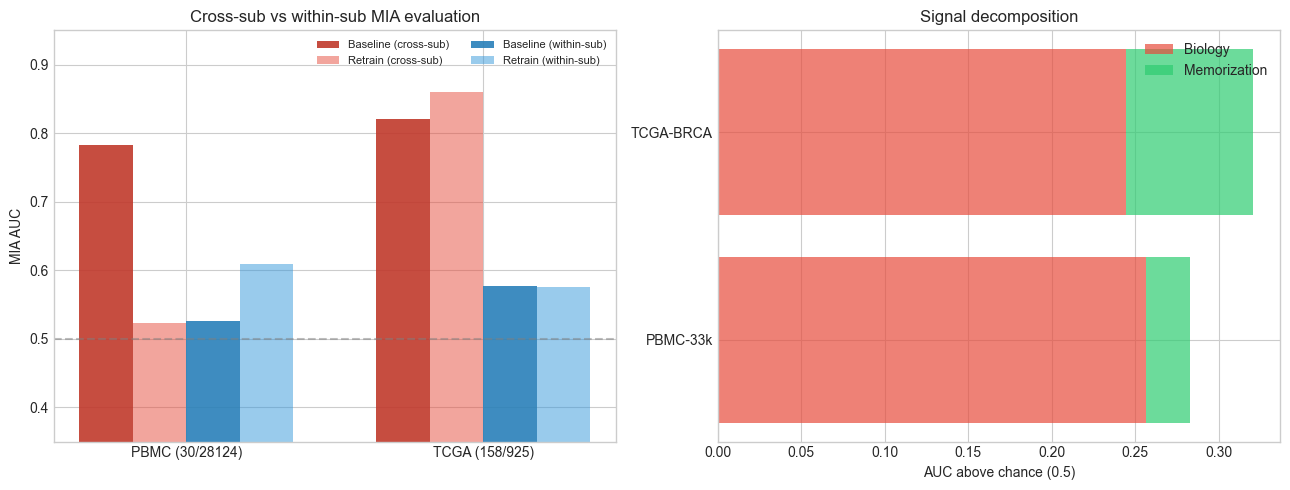

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(2)
w = 0.18

axes[0].bar(x - 1.5*w, [pbmc['cs_baseline'], tcga['cs_baseline']], w,
            label='Baseline (cross-sub)', color='#c0392b', alpha=0.9)
axes[0].bar(x - 0.5*w, [pbmc['cs_retrain'], tcga['cs_retrain']], w,
            label='Retrain (cross-sub)', color='#e74c3c', alpha=0.5)
axes[0].bar(x + 0.5*w, [pbmc['ws_baseline'], tcga['ws_baseline']], w,
            label='Baseline (within-sub)', color='#2980b9', alpha=0.9)
axes[0].bar(x + 1.5*w, [pbmc['ws_retrain'], tcga['ws_retrain']], w,
            label='Retrain (within-sub)', color='#3498db', alpha=0.5)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[0].set_xticks(x)
lbl_p = 'PBMC (' + str(pbmc['n_forget']) + '/' + str(pbmc['n_train']) + ')'
lbl_t = 'TCGA (' + str(tcga['n_forget']) + '/' + str(tcga['n_train']) + ')'
axes[0].set_xticklabels([lbl_p, lbl_t])
axes[0].set_ylabel('MIA AUC')
axes[0].set_ylim(0.35, 0.95)
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title('Cross-sub vs within-sub MIA evaluation')

for i, d in enumerate([pbmc, tcga]):
    biology = d['cs_baseline'] - d['ws_baseline']
    memorization = max(0, d['ws_baseline'] - 0.5)
    axes[1].barh(i, biology, left=0, color='#e74c3c', alpha=0.7,
                 label='Biology' if i == 0 else '')
    axes[1].barh(i, memorization, left=biology, color='#2ecc71', alpha=0.7,
                 label='Memorization' if i == 0 else '')

axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['PBMC-33k', 'TCGA-BRCA'])
axes[1].set_xlabel('AUC above chance (0.5)')
axes[1].set_title('Signal decomposition')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confound_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Fisher overlap comparison

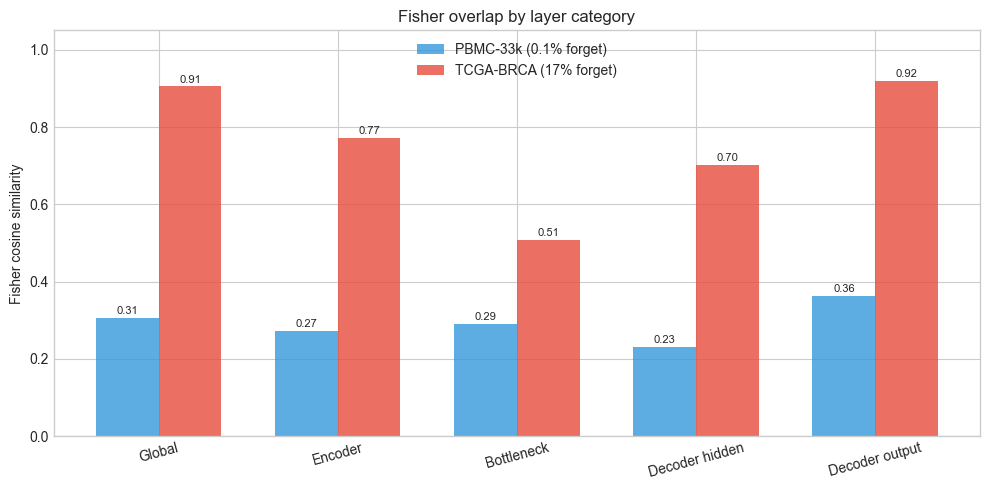

In [4]:
categories = ['Encoder', 'Bottleneck', 'Decoder hidden', 'Decoder output']
pbmc_layer_vals = [pbmc['fisher_layers'][c]['cosine'] for c in categories]
tcga_layer_vals = []
for c in categories:
    v = tcga['fisher_layers'].get(c, {})
    tcga_layer_vals.append(v['cosine'] if isinstance(v, dict) else v)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(categories) + 1)
labels = ['Global'] + categories
pbmc_all = [pbmc['fisher_global']] + pbmc_layer_vals
tcga_all = [tcga['fisher_global']] + tcga_layer_vals
w = 0.35

bars1 = ax.bar(x - w/2, pbmc_all, w, label='PBMC-33k (0.1% forget)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + w/2, tcga_all, w, label='TCGA-BRCA (17% forget)', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Fisher cosine similarity')
ax.set_title('Fisher overlap by layer category')
ax.legend()
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fisher_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-dataset summary

In [5]:
summary = pd.DataFrame({
    'PBMC-33k': {
        'Type': 'scRNA-seq',
        'Training samples': f'{pbmc["n_train"]:,}',
        'Genes': f'{pbmc["n_genes"]:,}',
        'Forget fraction': f'{pbmc["n_forget"]} ({100*pbmc["n_forget"]/pbmc["n_train"]:.1f}%)',
        'Baseline AUC (cross)': f'{pbmc["cs_baseline"]:.3f}',
        'Retrain AUC (cross)': f'{pbmc["cs_retrain"]:.3f}',
        'Baseline AUC (within)': f'{pbmc["ws_baseline"]:.3f}',
        'Retrain AUC (within)': f'{pbmc["ws_retrain"]:.3f}',
        'Fisher global': f'{pbmc["fisher_global"]:.3f}',
    },
    'TCGA-BRCA': {
        'Type': 'Bulk RNA-seq',
        'Training samples': f'{tcga["n_train"]:,}',
        'Genes': f'{tcga["n_genes"]:,}',
        'Forget fraction': f'{tcga["n_forget"]} ({100*tcga["n_forget"]/tcga["n_train"]:.1f}%)',
        'Baseline AUC (cross)': f'{tcga["cs_baseline"]:.3f}',
        'Retrain AUC (cross)': f'{tcga["cs_retrain"]:.3f}',
        'Baseline AUC (within)': f'{tcga["ws_baseline"]:.3f}',
        'Retrain AUC (within)': f'{tcga["ws_retrain"]:.3f}',
        'Fisher global': f'{tcga["fisher_global"]:.3f}',
    },
})
summary

,PBMC-33k,TCGA-BRCA
Type,scRNA-seq,Bulk RNA-seq
Training samples,"28,124",925
Genes,"2,000",978
Forget fraction,30 (0.1%),158 (17.1%)
Baseline AUC (cross),0.783,0.821
Retrain AUC (cross),0.523,0.860
Baseline AUC (within),0.527,0.576
Retrain AUC (within),0.609,0.576
Fisher global,0.306,0.905


Within-subtype matching eliminates the confound on both datasets.
Fisher overlap is 3x higher on TCGA-BRCA, driven by the larger forget fraction.

## Save results

In [6]:
findings = {
    'biology_confound': {
        'pbmc_confound_fraction': float((pbmc['cs_baseline'] - pbmc['ws_baseline']) / (pbmc['cs_baseline'] - 0.5)),
        'tcga_confound_fraction': float((tcga['cs_baseline'] - tcga['ws_baseline']) / (tcga['cs_baseline'] - 0.5)),
        'pbmc_cross': {'baseline': pbmc['cs_baseline'], 'retrain': pbmc['cs_retrain']},
        'pbmc_within': {'baseline': float(pbmc['ws_baseline']), 'retrain': float(pbmc['ws_retrain'])},
        'tcga_cross': {'baseline': tcga['cs_baseline'], 'retrain': tcga['cs_retrain']},
        'tcga_within': {'baseline': tcga['ws_baseline'], 'retrain': tcga['ws_retrain']},
    },
    'fisher_overlap': {
        'pbmc_global': pbmc['fisher_global'],
        'tcga_global': tcga['fisher_global'],
        'ratio': tcga['fisher_global'] / pbmc['fisher_global'],
    },
}
with open(OUTPUT_DIR / 'cross_domain_results.json', 'w') as f:
    json.dump(findings, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| Confound comparison | `outputs/cross_domain/confound_comparison.png` |
| Fisher comparison | `outputs/cross_domain/fisher_comparison.png` |
| Results JSON | `outputs/cross_domain/cross_domain_results.json` |